# 08. Lorenz-96 EnKF (localization & inflation)

이 노트북에서는 **Lorenz-96** 모델에 EnKF를 적용한다.

지금까지 다룬 Lorenz-63는 변수가 3개뿐이었다.
Lorenz-96는 변수가 $K = 40$ 개인 **공간 확장계**로, 실제 대기/해양 모델처럼
"격자 위의 값들"을 다룬다. 변수가 많아지면서 다음 두 가지가 비로소 중요해진다.

1. **inflation**: 앙상블 크기 $N$ 이 $K$ 보다 작으면 spread가 빠르게 과소평가되어
   필터가 발산(filter divergence)한다. 곱셈 inflation으로 spread를 보강한다.
2. **localization**: $N \ll K$ 이면 멀리 떨어진 격자점 사이의 표본 공분산이
   sampling error 때문에 잡음(spurious correlation)으로 나타난다.
   거리에 따라 공분산을 줄여(taper) 이 잡음을 억제한다.

이번 실습의 목표는 다음과 같다.

1. Lorenz-96 모델을 RK4로 적분한다.
2. 작은 앙상블($N=20 < K=40$)로 EnKF를 돌려 filter divergence를 직접 본다.
3. inflation을 추가해 발산을 막는다.
4. localization을 추가해 정확도를 더 끌어올린다.

## 1. 라이브러리 불러오기

In [1]:
import sys
from pathlib import Path

# --- bootstrap: 프로젝트 루트의 src/ 를 sys.path 에 추가해 lorenz_da import 를 보장한다 ---
#     editable 설치 위치에 의존하지 않으므로, 프로젝트를 다른 경로로 옮겨도 동작한다.
_p = Path.cwd().resolve()
for _d in (_p, *_p.parents):
    if (_d / "pyproject.toml").exists() or (_d / ".git").exists():
        if str(_d / "src") not in sys.path:
            sys.path.insert(0, str(_d / "src"))
        break

import numpy as np
import matplotlib.pyplot as plt

from lorenz_da.models.lorenz96 import lorenz96_rhs, lorenz96_default_initial_condition
from lorenz_da.numerics.rk4 import rk4_step, integrate_rk4
from lorenz_da.observations.operator import identity_observation_operator
from lorenz_da.observations.synthetic import (
    make_observation_indices,
    generate_synthetic_observations,
)
from lorenz_da.assimilation.enkf import (
    initialize_ensemble,
    multiplicative_inflation,
    stochastic_enkf_analysis,
)
from lorenz_da.assimilation.localization import localization_matrix
from lorenz_da.utils.diagnostics import rmse_time_series, mean_rmse

from lorenz_da.utils.io import find_project_root, get_output_dirs

## 2. 프로젝트 경로 설정

In [2]:
PROJECT_ROOT = find_project_root()
paths = get_output_dirs(PROJECT_ROOT)
FIGURE_DIR = paths["figures"]
TRAJECTORY_DIR = paths["trajectories"]
ASSIM_DIR = paths["assimilation"]
CKPT_DIR = paths["checkpoints"]

print("Project root:", PROJECT_ROOT)
print("Figure directory:", FIGURE_DIR)

Project root: /Users/sanggyu/projects/lorenz-da-lab
Figure directory: /Users/sanggyu/projects/lorenz-da-lab/outputs/figures


## 3. Lorenz-96 모델

Lorenz-96 방정식은 다음과 같다 (주기경계, $k = 0, \dots, K-1$).

$$
\frac{dx_k}{dt} = (x_{k+1} - x_{k-2})\, x_{k-1} - x_k + F
$$

- $(x_{k+1} - x_{k-2})\, x_{k-1}$: 이류(advection)와 비슷한 비선형 항
- $-x_k$: 소산(damping)
- $F$: 외부 강제(forcing). $F = 8$ 이면 chaotic하다.

Lorenz-63보다 비선형성이 더 단단해서 Euler로는 정확도가 부족하다.
따라서 이번에는 **RK4** 적분기를 사용한다.

In [3]:
K = 40
F = 8.0
dt = 0.025

# spinup 후 truth 생성
x_seed = lorenz96_default_initial_condition(K=K, F=F)
spinup = integrate_rk4(x_seed, dt=dt, nsteps=1000, rhs_func=lorenz96_rhs)
x0_true = spinup[-1]

nsteps = 1000
truth = integrate_rk4(x0_true, dt=dt, nsteps=nsteps, rhs_func=lorenz96_rhs)
time = np.arange(nsteps + 1) * dt
print("truth shape:", truth.shape)

truth shape: (1001, 40)


## 4. Lorenz-96 attractor 시각화 (Hovmöller diagram)

가로축을 격자 index $k$, 세로축을 시간으로 두고 $x_k(t)$ 를 색으로 그린다.
서쪽으로 전파하는 파동 구조가 보인다. 이것이 Lorenz-96의 "날씨"이다.

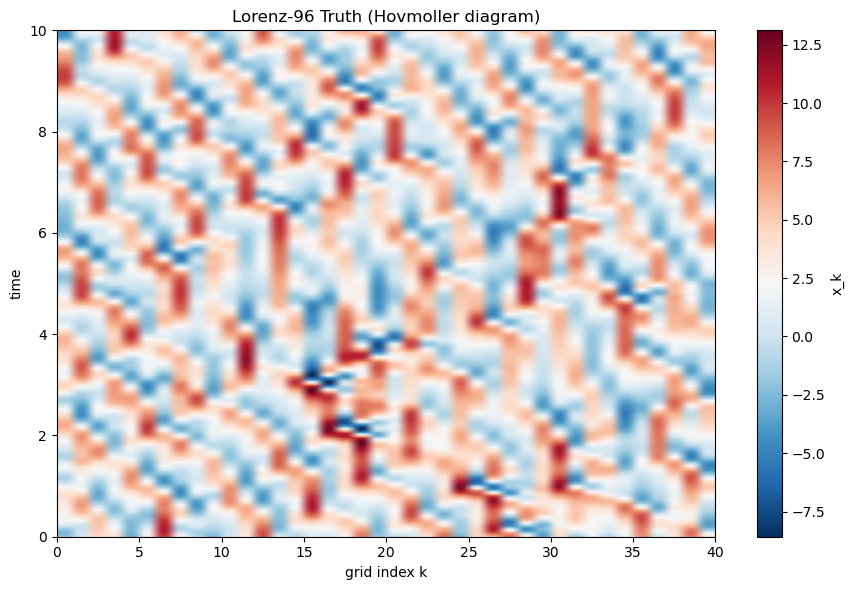

Saved figure: /Users/sanggyu/projects/lorenz-da-lab/outputs/figures/08_lorenz96_hovmoller_truth.png


In [4]:
fig, ax = plt.subplots(figsize=(9, 6))
im = ax.imshow(
    truth[:400], aspect="auto", cmap="RdBu_r", origin="lower",
    extent=[0, K, 0, time[400]],
)
ax.set_xlabel("grid index k")
ax.set_ylabel("time")
ax.set_title("Lorenz-96 Truth (Hovmoller diagram)")
fig.colorbar(im, ax=ax, label="x_k")
fig.tight_layout()
fig_path = FIGURE_DIR / "08_lorenz96_hovmoller_truth.png"
fig.savefig(fig_path, dpi=150)
plt.show()
print("Saved figure:", fig_path)

## 5. 관측과 초기 앙상블

- 모든 격자점을 관측한다 ($H = I$), 관측오차 표준편차 `obs_std = 1.0`.
- 관측은 4 step마다 ($\Delta t_{obs} = 0.1$).
- 앙상블 크기 `N = 20`. 이는 $K = 40$ 보다 **작으므로** sampling error가 중요해진다.
- 초기 앙상블은 truth와 다른 climatology 상태 주변에 둔다.

In [5]:
obs_interval = 4
obs_std = 1.0
seed = 42

H = identity_observation_operator(K)
R = (obs_std**2) * np.eye(K)
obs_indices = make_observation_indices(nsteps=nsteps, obs_interval=obs_interval)
obs_index_set = set(int(i) for i in obs_indices)

rng_obs = np.random.default_rng(seed)
observations = generate_synthetic_observations(
    truth=truth, obs_indices=obs_indices, H=H, obs_std=obs_std, rng=rng_obs
)

# 초기 앙상블: truth와 다른 attractor 상태 주변
N = 20
x0_bg = spinup[300]  # truth 시작과 다른 climatology 상태
rng = np.random.default_rng(seed)
ensemble0 = initialize_ensemble(x0_bg, ensemble_size=N, spread=3.0, rng=rng)

print("관측 개수:", len(obs_indices), "| 앙상블 크기 N:", N, "| 상태차원 K:", K)
print("초기 앙상블 평균 RMSE vs truth:", mean_rmse(np.tile(x0_bg, (1, 1)), truth[:1]))

관측 개수: 250 | 앙상블 크기 N: 20 | 상태차원 K: 40
초기 앙상블 평균 RMSE vs truth: 5.134590170310753


## 6. EnKF 사이클 함수

07번과 같은 forecast–analysis 구조이지만, 이번에는

- 모델이 Lorenz-96 (RK4),
- inflation과 localization을 선택적으로 적용

한다는 점이 다르다. localization 행렬은 `stochastic_enkf_analysis`에 그대로 넘긴다.

In [6]:
def run_enkf_l96(ensemble_init, inflation_factor=1.0, loc_matrix=None, seed=seed):
    rng = np.random.default_rng(seed)
    ens = ensemble_init.copy()
    mean_hist = np.zeros((nsteps + 1, K))
    mean_hist[0] = ens.mean(axis=0)
    c = 0
    for n in range(nsteps):
        for j in range(N):
            ens[j] = rk4_step(ens[j], dt, lorenz96_rhs)
        if (n + 1) in obs_index_set:
            if inflation_factor != 1.0:
                ens = multiplicative_inflation(ens, inflation_factor)
            ens = stochastic_enkf_analysis(
                ens, observations[c], H, R, rng=rng, localization=loc_matrix
            )
            c += 1
        mean_hist[n + 1] = ens.mean(axis=0)
    return mean_hist

## 7. 세 가지 경우 비교

작은 앙상블에서 inflation과 localization이 각각 어떤 역할을 하는지 본다.

- **A. inflation 없음, localization 없음** → 앙상블 spread가 무너져 filter divergence가 일어나기 쉽다.
- **B. inflation만** → spread 붕괴를 막아 발산을 억제한다.
- **C. inflation + localization** → spurious correlation까지 억제해 가장 정확하다.

In [7]:
loc = localization_matrix(K, length_scale=4.0)

mean_A = run_enkf_l96(ensemble0, inflation_factor=1.0, loc_matrix=None)
mean_B = run_enkf_l96(ensemble0, inflation_factor=1.08, loc_matrix=None)
mean_C = run_enkf_l96(ensemble0, inflation_factor=1.08, loc_matrix=loc)

# 초반 spinup(처음 t<5)은 제외하고 평균 RMSE를 잰다.
warmup = int(5.0 / dt)
def avg_rmse(mean_hist):
    return mean_rmse(mean_hist[warmup:], truth[warmup:])

print("평균 RMSE (warmup 이후)")
print(f"  A. inflation X, loc X : {avg_rmse(mean_A):.4f}")
print(f"  B. inflation O, loc X : {avg_rmse(mean_B):.4f}")
print(f"  C. inflation O, loc O : {avg_rmse(mean_C):.4f}")

평균 RMSE (warmup 이후)
  A. inflation X, loc X : 4.3113
  B. inflation O, loc X : 3.8795
  C. inflation O, loc O : 0.3498


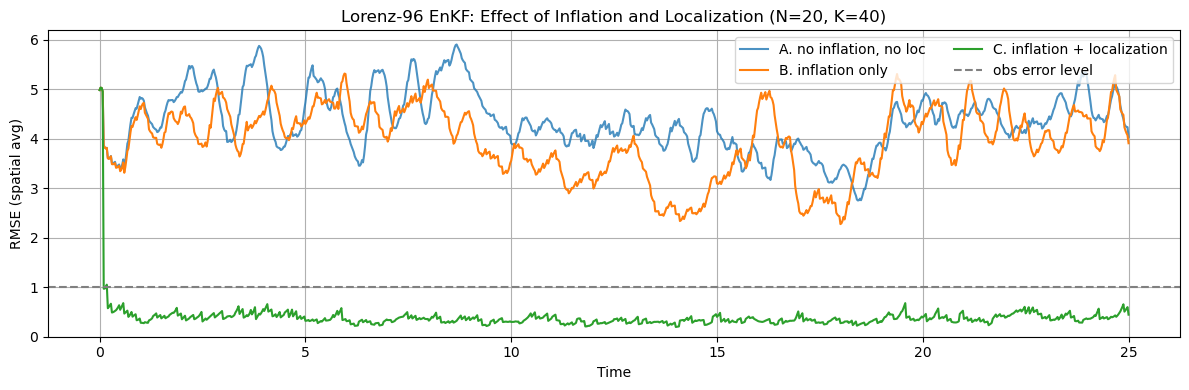

Saved figure: /Users/sanggyu/projects/lorenz-da-lab/outputs/figures/08_lorenz96_enkf_rmse.png


In [8]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(time, rmse_time_series(mean_A, truth), label="A. no inflation, no loc", alpha=0.8)
ax.plot(time, rmse_time_series(mean_B, truth), label="B. inflation only")
ax.plot(time, rmse_time_series(mean_C, truth), label="C. inflation + localization")
ax.axhline(obs_std, linestyle="--", color="gray", label="obs error level")
ax.set_xlabel("Time"); ax.set_ylabel("RMSE (spatial avg)")
ax.set_title("Lorenz-96 EnKF: Effect of Inflation and Localization (N=20, K=40)")
ax.legend(ncol=2); ax.grid(True)
ax.set_ylim(0, None)
fig.tight_layout()
fig_path = FIGURE_DIR / "08_lorenz96_enkf_rmse.png"
fig.savefig(fig_path, dpi=150)
plt.show()
print("Saved figure:", fig_path)

## 8. 분석 오차 Hovmöller (최적 경우)

inflation + localization 경우의 분석 오차 $|\,\text{analysis} - \text{truth}\,|$ 를
시공간 그림으로 본다. 자료동화가 잘 되면 시간이 지날수록 오차가 작게 유지된다.

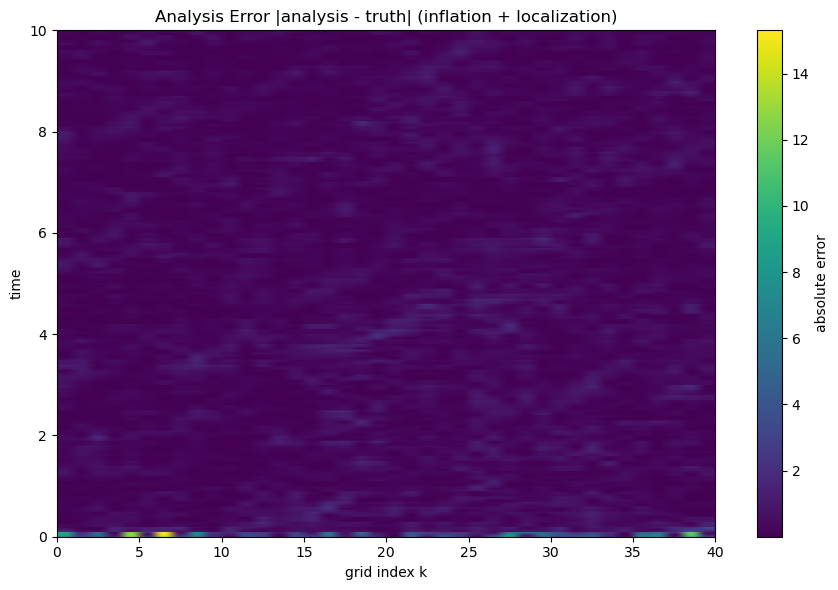

Saved figure: /Users/sanggyu/projects/lorenz-da-lab/outputs/figures/08_lorenz96_error_hovmoller.png


In [9]:
err_C = np.abs(mean_C - truth)

fig, ax = plt.subplots(figsize=(9, 6))
im = ax.imshow(
    err_C[:400], aspect="auto", cmap="viridis", origin="lower",
    extent=[0, K, 0, time[400]],
)
ax.set_xlabel("grid index k"); ax.set_ylabel("time")
ax.set_title("Analysis Error |analysis - truth| (inflation + localization)")
fig.colorbar(im, ax=ax, label="absolute error")
fig.tight_layout()
fig_path = FIGURE_DIR / "08_lorenz96_error_hovmoller.png"
fig.savefig(fig_path, dpi=150)
plt.show()
print("Saved figure:", fig_path)

## 9. localization 행렬 시각화

Gaspari-Cohn localization 행렬 $L$ 은 대각이 1이고, 멀리 떨어진 격자점일수록 0에 가깝다.
표본 공분산 $P^f$ 에 $L$ 을 원소별로 곱하면 먼 거리의 잡음 상관이 사라진다.

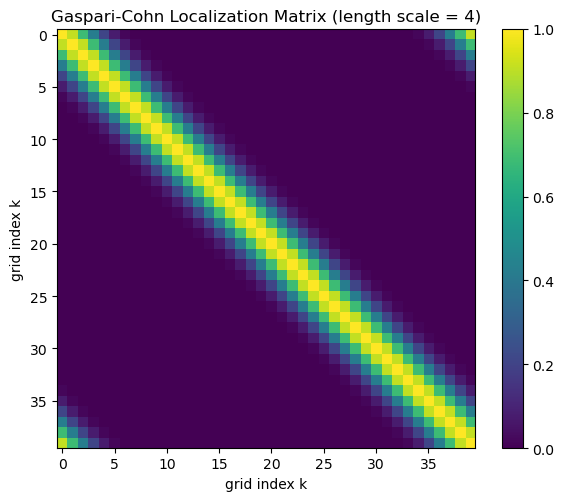

Saved figure: /Users/sanggyu/projects/lorenz-da-lab/outputs/figures/08_lorenz96_localization_matrix.png


In [10]:
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(loc, cmap="viridis")
ax.set_xlabel("grid index k"); ax.set_ylabel("grid index k")
ax.set_title("Gaspari-Cohn Localization Matrix (length scale = 4)")
fig.colorbar(im, ax=ax)
fig.tight_layout()
fig_path = FIGURE_DIR / "08_lorenz96_localization_matrix.png"
fig.savefig(fig_path, dpi=150)
plt.show()
print("Saved figure:", fig_path)

## 10. 결과 저장

In [11]:
np.save(TRAJECTORY_DIR / "08_lorenz96_truth.npy", truth)
np.save(ASSIM_DIR / "08_lorenz96_enkf_mean_best.npy", mean_C)

with open(ASSIM_DIR / "08_lorenz96_enkf_summary.txt", "w", encoding="utf-8") as f:
    f.write("Lorenz-96 EnKF 실습 요약\n\n")
    f.write(f"K: {K}, F: {F}, dt: {dt}, nsteps: {nsteps}\n")
    f.write(f"N: {N}, obs_interval: {obs_interval}, obs_std: {obs_std}\n\n")
    f.write("평균 RMSE (warmup 이후)\n")
    f.write(f"A. inflation X, loc X : {avg_rmse(mean_A):.6f}\n")
    f.write(f"B. inflation O, loc X : {avg_rmse(mean_B):.6f}\n")
    f.write(f"C. inflation O, loc O : {avg_rmse(mean_C):.6f}\n")
print("Saved Lorenz-96 EnKF results to:", ASSIM_DIR)

Saved Lorenz-96 EnKF results to: /Users/sanggyu/projects/lorenz-da-lab/outputs/assimilation


## 11. 이번 실습 정리

이번 노트북에서는 Lorenz-96 (K=40) 모델에 EnKF를 적용했다.

확인한 내용은 다음과 같다.

1. Lorenz-96는 격자 위의 변수를 다루는 공간 확장계이고, RK4로 적분했다.
2. 앙상블 크기가 상태차원보다 작으면($N=20 < K=40$) sampling error가 커진다.
3. **inflation** 은 앙상블 spread가 무너지는 filter divergence를 막는다.
4. **localization** 은 멀리 떨어진 격자점 사이의 잡음 상관을 억제해 정확도를 더 높인다.
5. 07번의 Lorenz-63에서는 저차원이라 둘 다 거의 필요 없었지만,
   고차원에서는 둘 다 사실상 필수임을 직접 확인했다.

이로써 Lorenz 자료동화 실습의 큰 그림이 완성된다.

- 변분 계열: 02 (3D-Var) → 03 (TLM) → 04 (adjoint) → 05 (4D-Var)
- 앙상블 계열: 02 → 07 (EnKF, L63) → 08 (EnKF, L96) → 09 (EnOI)
- AI: 06 (surrogate model)

In [12]:
print("여덟 번째 실습 완료")

여덟 번째 실습 완료
